In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

import os
import tensorflow as tf
import keras
import cv2

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from tensorflow.keras import layers , models, optimizers

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.applications import ResNet50V2

/Users/harshareddy/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import os
import pandas as pd

def Classes_Count(path, name):
    Classes_Dict = {}

    for Class in os.listdir(path):
        Full_Path = os.path.join(path, Class)  # ✅ Properly joins paths

        if os.path.isdir(Full_Path):  # ✅ Ensures it's a directory
            Classes_Dict[Class] = len(os.listdir(Full_Path))

    df = pd.DataFrame(Classes_Dict, index=[name])
    return df

train_dir = '/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/train'
test_dir = '/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/test'

# Check if directories exist before proceeding
if not os.path.exists(train_dir):
    print(f"Error: {train_dir} does not exist.")
if not os.path.exists(test_dir):
    print(f"Error: {test_dir} does not exist.")

Train_Count = Classes_Count(train_dir, 'Train').transpose().sort_values(by="Train", ascending=False)
Test_Count = Classes_Count(test_dir, 'Test').transpose().sort_values(by="Test", ascending=False)

print(Train_Count)
print(Test_Count)


          Train
happy      7215
neutral    4965
sad        4830
fear       4097
angry      3995
surprise   3171
disgust     436
          Test
happy     1774
sad       1247
neutral   1233
fear      1024
angry      958
surprise   831
disgust    111


In [3]:
pd.concat([Train_Count,Test_Count] , axis=1)

,Train,Test
happy,7215,1774
neutral,4965,1233
sad,4830,1247
fear,4097,1024
angry,3995,958
surprise,3171,831
disgust,436,111


<Axes: >

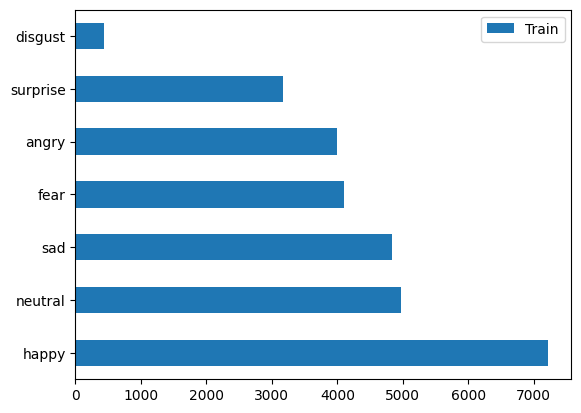

In [4]:
Train_Count.plot(kind='barh')

<Axes: >

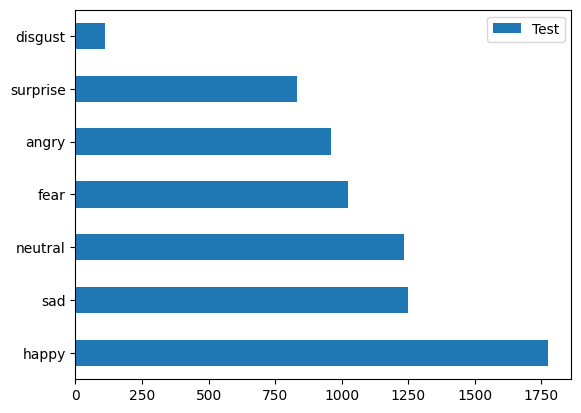

In [5]:
Test_Count.plot(kind='barh')

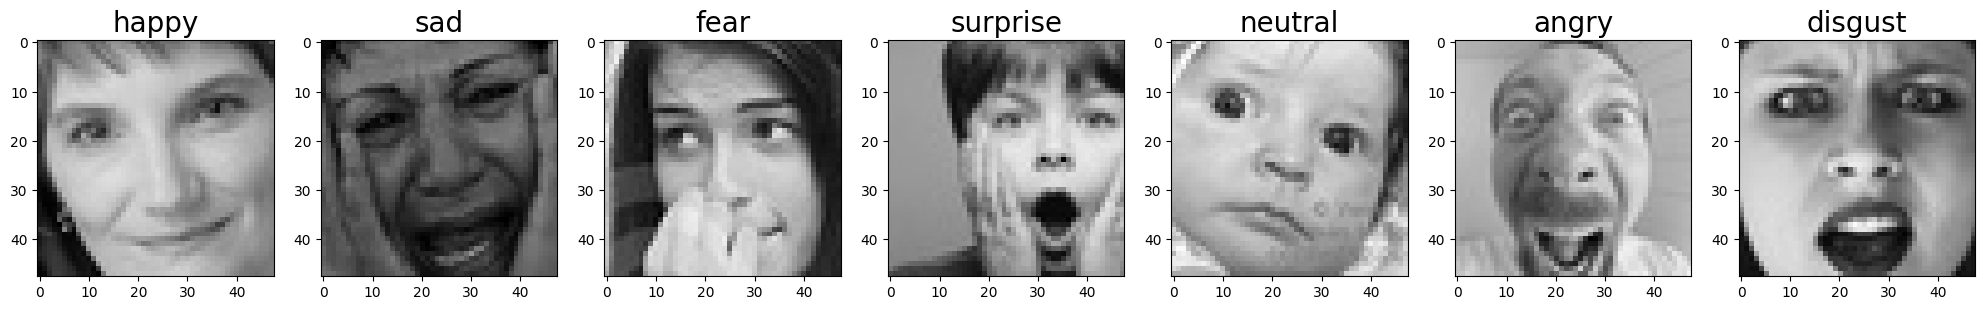

In [6]:
import os
import cv2
import matplotlib.pyplot as plt

plt.style.use('default')
plt.figure(figsize=(25, 8))
image_count = 1
BASE_URL = '/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/train'

if not os.path.exists(BASE_URL):
    print(f"Error: The directory '{BASE_URL}' does not exist.")
else:
    for directory in os.listdir(BASE_URL):
        if directory[0] != '.':  # Ignore hidden files
            dir_path = os.path.join(BASE_URL, directory)
            for i, file in enumerate(os.listdir(dir_path)):
                if i == 1:  # Display only one image per class
                    break
                else:
                    fig = plt.subplot(1, 7, image_count)
                    image_count += 1
                    image_path = os.path.join(dir_path, file)
                    image = cv2.imread(image_path)
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to correct color format
                    plt.imshow(image)
                    plt.title(directory, fontsize=20)

    plt.show()


In [7]:
img_shape = 48
batch_size = 64
train_data_path = '/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/train'
test_data_path = '/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/test'

In [8]:
train_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
        # Data Augmentation
        rotation_range=10,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
    )


test_preprocessor = ImageDataGenerator(
    rescale = 1 / 255.,
)

train_data = train_preprocessor.flow_from_directory(
    train_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size,
    subset='training',
)


test_data = test_preprocessor.flow_from_directory(
    test_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [9]:
def Create_CNN_Model():

    model = Sequential()

    #CNN1
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(img_shape, img_shape, 3)))
    model.add(BatchNormalization())
    model.add(Conv2D(64,(3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.25))

    #CNN2
    model.add(Conv2D(64, (3,3), activation='relu', ))
    model.add(BatchNormalization())
    model.add(Conv2D(128,(3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.25))

    #CNN3
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(Conv2D(256,(3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.25))


    #Output
    model.add(Flatten())

    model.add(Dense(1024, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(32, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.25))

    model.add(Dense(7,activation='softmax'))


    return model

In [10]:
CNN_Model = Create_CNN_Model()

CNN_Model.summary()

CNN_Model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 46, 46, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 46, 46, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 46, 46, 64)        256       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 64)        0         
 D)                                                              
                                                        

In [11]:
# Create Callback Checkpoint
checkpoint_path = "CNN_Model_Checkpoint"

Checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)

# Create Early Stopping Callback to monitor the accuracy
Early_Stopping = EarlyStopping(monitor = 'val_accuracy', patience = 15, restore_best_weights = True, verbose=1)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning rate
Reducing_LR = tf.keras.callbacks.ReduceLROnPlateau( monitor='val_loss',
                                                  factor=0.2,
                                                  patience=2,
#                                                   min_lr=0.000005,
                                                  verbose=1)

callbacks = [Early_Stopping, Reducing_LR]

steps_per_epoch = train_data.n // train_data.batch_size
validation_steps = test_data.n // test_data.batch_size

In [12]:
CNN_history = CNN_Model.fit( train_data , validation_data= test_data , epochs=50, batch_size= batch_size,
                            callbacks=callbacks, steps_per_epoch= steps_per_epoch, validation_steps=validation_steps)

Epoch 1/50
448/448 [==============================] - 139s 309ms/step - loss: 2.0238 - accuracy: 0.2057 - val_loss: 1.8440 - val_accuracy: 0.2499 - lr: 0.0010
Epoch 2/50
448/448 [==============================] - 147s 327ms/step - loss: 1.7697 - accuracy: 0.2745 - val_loss: 1.7884 - val_accuracy: 0.2905 - lr: 0.0010
Epoch 3/50
448/448 [==============================] - 148s 331ms/step - loss: 1.6494 - accuracy: 0.3427 - val_loss: 1.5466 - val_accuracy: 0.3951 - lr: 0.0010
Epoch 4/50
448/448 [==============================] - 150s 335ms/step - loss: 1.5109 - accuracy: 0.4131 - val_loss: 1.7404 - val_accuracy: 0.3213 - lr: 0.0010
Epoch 5/50
448/448 [==============================] - 172s 385ms/step - loss: 1.4254 - accuracy: 0.4554 - val_loss: 1.3870 - val_accuracy: 0.4661 - lr: 0.0010
Epoch 6/50
448/448 [==============================] - 197s 440ms/step - loss: 1.3555 - accuracy: 0.4879 - val_loss: 1.6729 - val_accuracy: 0.3856 - lr: 0.0010
Epoch 7/50
448/448 [==========================

In [13]:
CNN_Score = CNN_Model.evaluate(test_data)

print("    Test Loss: {:.5f}".format(CNN_Score[0]))
print("Test Accuracy: {:.2f}%".format(CNN_Score[1] * 100))

113/113 [==============================] - 16s 142ms/step - loss: 0.9438 - accuracy: 0.6521
    Test Loss: 0.94382
Test Accuracy: 65.21%


In [14]:
def plot_curves(history):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"]))

    plt.figure(figsize=(15,5))

    #plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label = "training_loss")
    plt.plot(epochs, val_loss, label = "val_loss")
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()

    #plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label = "training_accuracy")
    plt.plot(epochs, val_accuracy, label = "val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

  #plt.tight_layout()

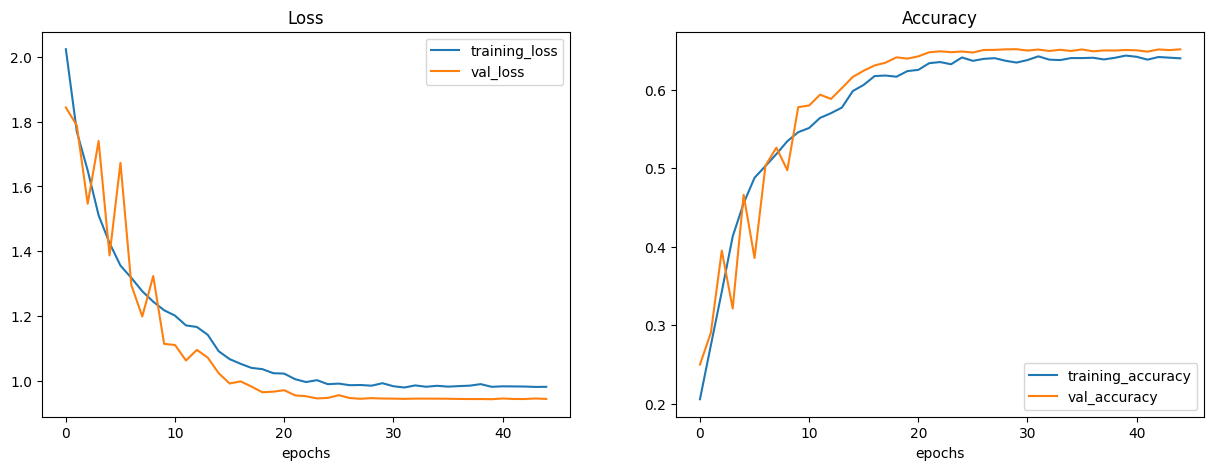

In [15]:
plot_curves(CNN_history)

In [16]:
CNN_Predictions = CNN_Model.predict(test_data)

# Choosing highest probalbilty class in every prediction
CNN_Predictions = np.argmax(CNN_Predictions, axis=1)

113/113 [==============================] - 16s 141ms/step


In [17]:
test_data.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

Text(0.5, 1.0, 'CNN Confusion Matrix')

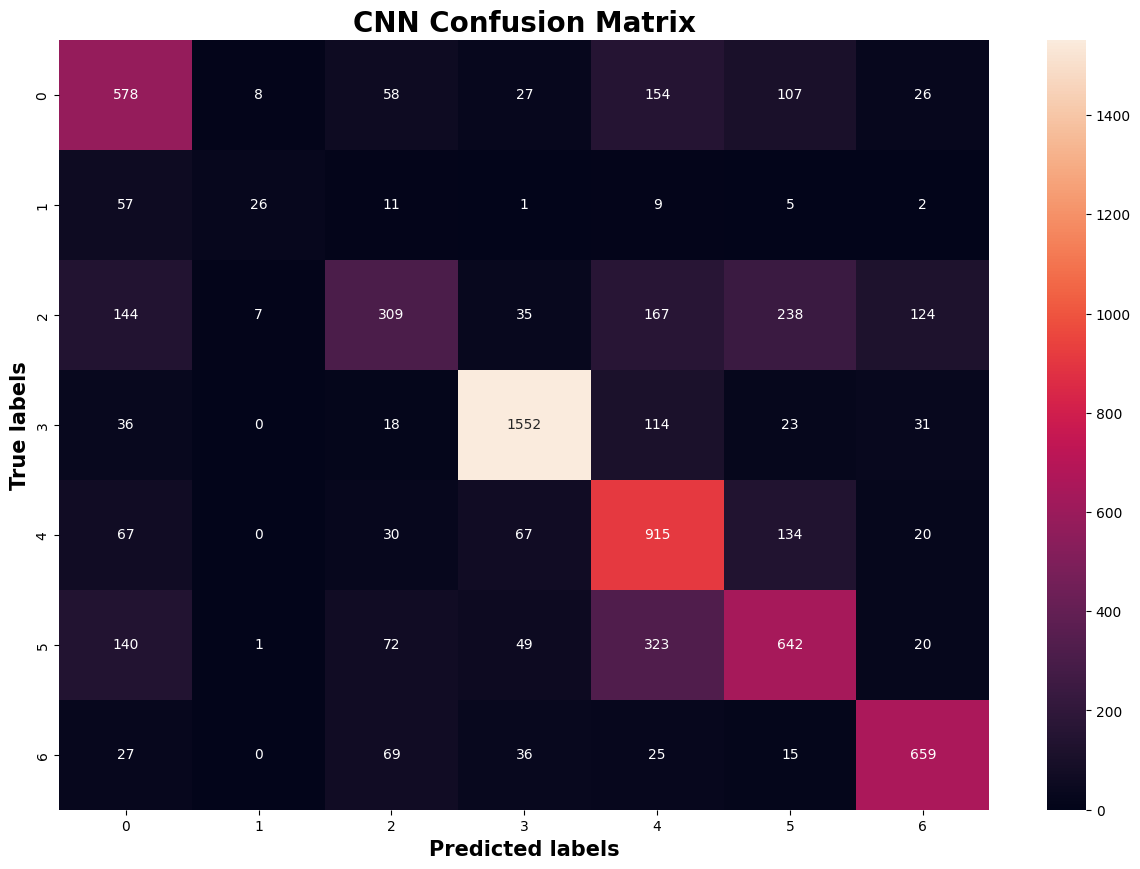

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax= plt.subplots(figsize=(15,10))

cm=confusion_matrix(test_data.labels, CNN_Predictions)

sns.heatmap(cm, annot=True, fmt='g', ax=ax)

ax.set_xlabel('Predicted labels',fontsize=15, fontweight='bold')
ax.set_ylabel('True labels', fontsize=15, fontweight='bold')
ax.set_title('CNN Confusion Matrix', fontsize=20, fontweight='bold')

In [19]:
# specifing new image shape for resnet
img_shape = 224
batch_size = 64
train_data_path = '/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/train'
test_data_path = '/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/test'

In [20]:
train_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
        rotation_range=10,
        zoom_range=0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest',
    )


test_preprocessor = ImageDataGenerator(
    rescale = 1 / 255.,
)

train_data = train_preprocessor.flow_from_directory(
    train_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size,
    subset='training',
)

test_data = test_preprocessor.flow_from_directory(
    test_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [21]:
# 224,224,3
ResNet50V2 = tf.keras.applications.ResNet50V2(input_shape=(224, 224, 3),
                                               include_top= False,
                                               weights='imagenet'
                                               )

#ResNet50V2.summary()

In [22]:
# Freezing all layers except last 50

ResNet50V2.trainable = True

for layer in ResNet50V2.layers[:-50]:
    layer.trainable = False

In [23]:
def Create_ResNet50V2_Model():

    model = Sequential([
                      ResNet50V2,
                      Dropout(.25),
                      BatchNormalization(),
                      Flatten(),
                      Dense(64, activation='relu'),
                      BatchNormalization(),
                      Dropout(.5),
                      Dense(7,activation='softmax')
                    ])
    return model

In [24]:
ResNet50V2_Model = Create_ResNet50V2_Model()

ResNet50V2_Model.summary()

ResNet50V2_Model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 dropout_9 (Dropout)         (None, 7, 7, 2048)        0         
                                                                 
 batch_normalization_12 (Ba  (None, 7, 7, 2048)        8192      
 tchNormalization)                                               
                                                                 
 flatten_1 (Flatten)         (None, 100352)            0         
                                                                 
 dense_7 (Dense)             (None, 64)                6422592   
                                                                 
 batch_normalization_13 (Ba  (None, 64)                256       
 tchNormalization)                                    

In [25]:
# Create Callback Checkpoint
checkpoint_path = "ResNet50V2_Model_Checkpoint"

Checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)

# Create Early Stopping Callback to monitor the accuracy
Early_Stopping = EarlyStopping(monitor = 'val_accuracy', patience = 7, restore_best_weights = True, verbose=1)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning
Reducing_LR = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,
                                                  patience=2,
#                                                   min_lr=0.00005,
                                                  verbose=1)

callbacks = [Early_Stopping, Reducing_LR]

steps_per_epoch = train_data.n // train_data.batch_size
validation_steps = test_data.n // test_data.batch_size

In [26]:
ResNet50V2_history = ResNet50V2_Model.fit(train_data ,validation_data = test_data , epochs=30, batch_size=batch_size,
                                         callbacks = callbacks, steps_per_epoch=steps_per_epoch, validation_steps=validation_steps)

Epoch 1/30
448/448 [==============================] - 4996s 11s/step - loss: 1.5199 - accuracy: 0.4658 - val_loss: 3.3262 - val_accuracy: 0.5149 - lr: 0.0010
Epoch 2/30
448/448 [==============================] - 2148s 5s/step - loss: 1.2197 - accuracy: 0.5636 - val_loss: 1.2833 - val_accuracy: 0.5996 - lr: 0.0010
Epoch 3/30
448/448 [==============================] - 2569s 6s/step - loss: 1.1906 - accuracy: 0.5752 - val_loss: 1.7149 - val_accuracy: 0.5299 - lr: 0.0010
Epoch 4/30
448/448 [==============================] - 2589s 6s/step - loss: 1.1529 - accuracy: 0.5832 - val_loss: 1.0379 - val_accuracy: 0.6191 - lr: 0.0010
Epoch 5/30
448/448 [==============================] - 2592s 6s/step - loss: 1.0709 - accuracy: 0.6141 - val_loss: 1.0144 - val_accuracy: 0.6233 - lr: 0.0010
Epoch 6/30
448/448 [==============================] - 2578s 6s/step - loss: 1.0344 - accuracy: 0.6272 - val_loss: 1.1863 - val_accuracy: 0.6311 - lr: 0.0010
Epoch 7/30
448/448 [==============================] - 234

In [27]:
ResNet50V2_Score = ResNet50V2_Model.evaluate(test_data)

print("    Test Loss: {:.5f}".format(ResNet50V2_Score[0]))
print("Test Accuracy: {:.2f}%".format(ResNet50V2_Score[1] * 100))

113/113 [==============================] - 355s 3s/step - loss: 0.9441 - accuracy: 0.6807
    Test Loss: 0.94410
Test Accuracy: 68.07%


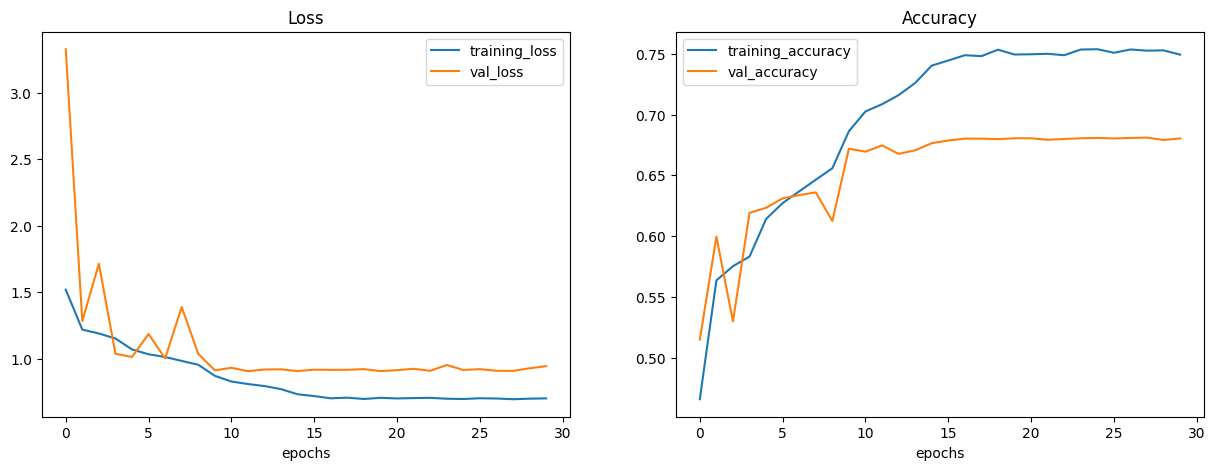

In [28]:
plot_curves(ResNet50V2_history)

In [29]:
ResNet50V2_Predictions = ResNet50V2_Model.predict(test_data)

# Choosing highest probalbilty class in every prediction
ResNet50V2_Predictions = np.argmax(ResNet50V2_Predictions, axis=1)

113/113 [==============================] - 361s 3s/step


Text(0.5, 1.0, 'ResNet50V2 Confusion Matrix')

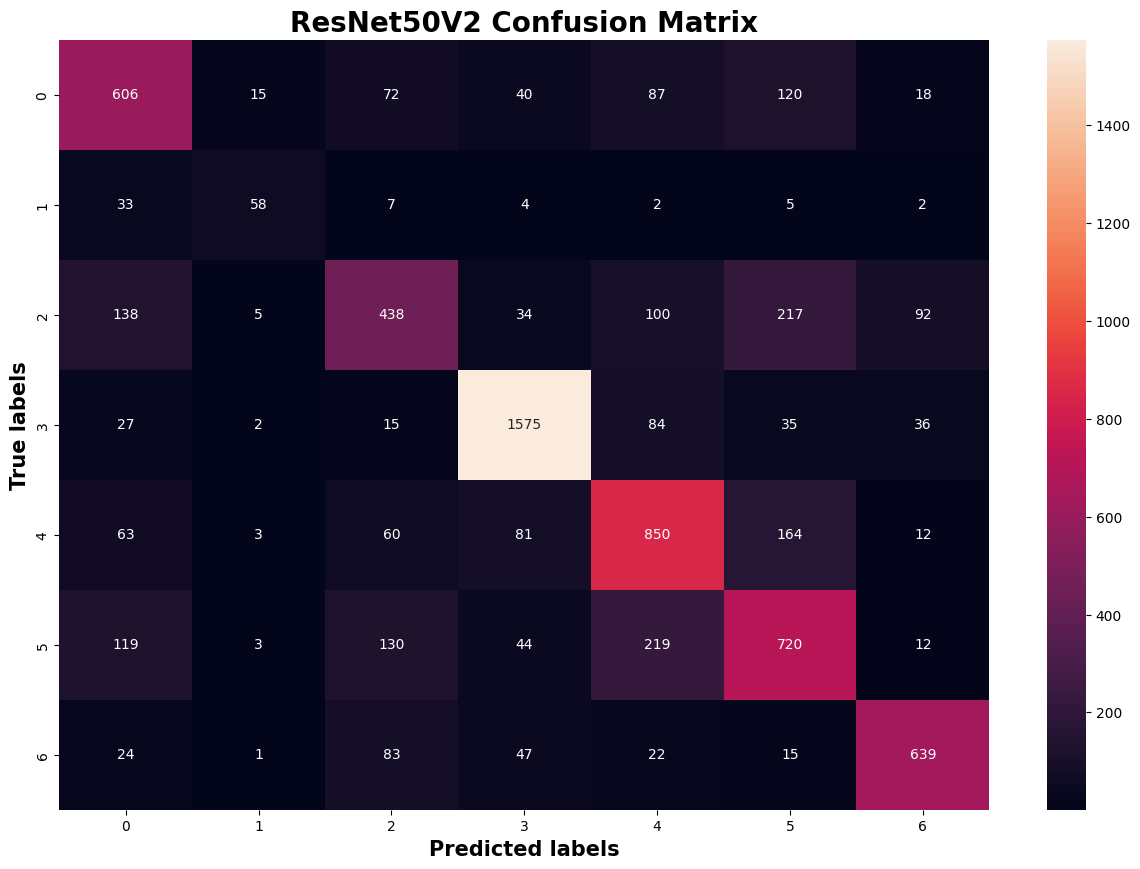

In [30]:
fig , ax= plt.subplots(figsize=(15,10))

cm=confusion_matrix(test_data.labels, ResNet50V2_Predictions)

sns.heatmap(cm, annot=True, fmt='g', ax=ax)

ax.set_xlabel('Predicted labels',fontsize=15, fontweight='bold')
ax.set_ylabel('True labels', fontsize=15, fontweight='bold')
ax.set_title('ResNet50V2 Confusion Matrix', fontsize=20, fontweight='bold')

In [31]:
Emotion_Classes = ['Angry',
                  'Disgust',
                  'Fear',
                  'Happy',
                  'Neutral',
                  'Sad',
                  'Surprise']

In [32]:
# Shuffling Test Data to show diffrent classes
test_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
    )

test_generator = test_preprocessor.flow_from_directory(
    test_data_path,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=True,
    batch_size=batch_size,
)

Found 7178 images belonging to 7 classes.


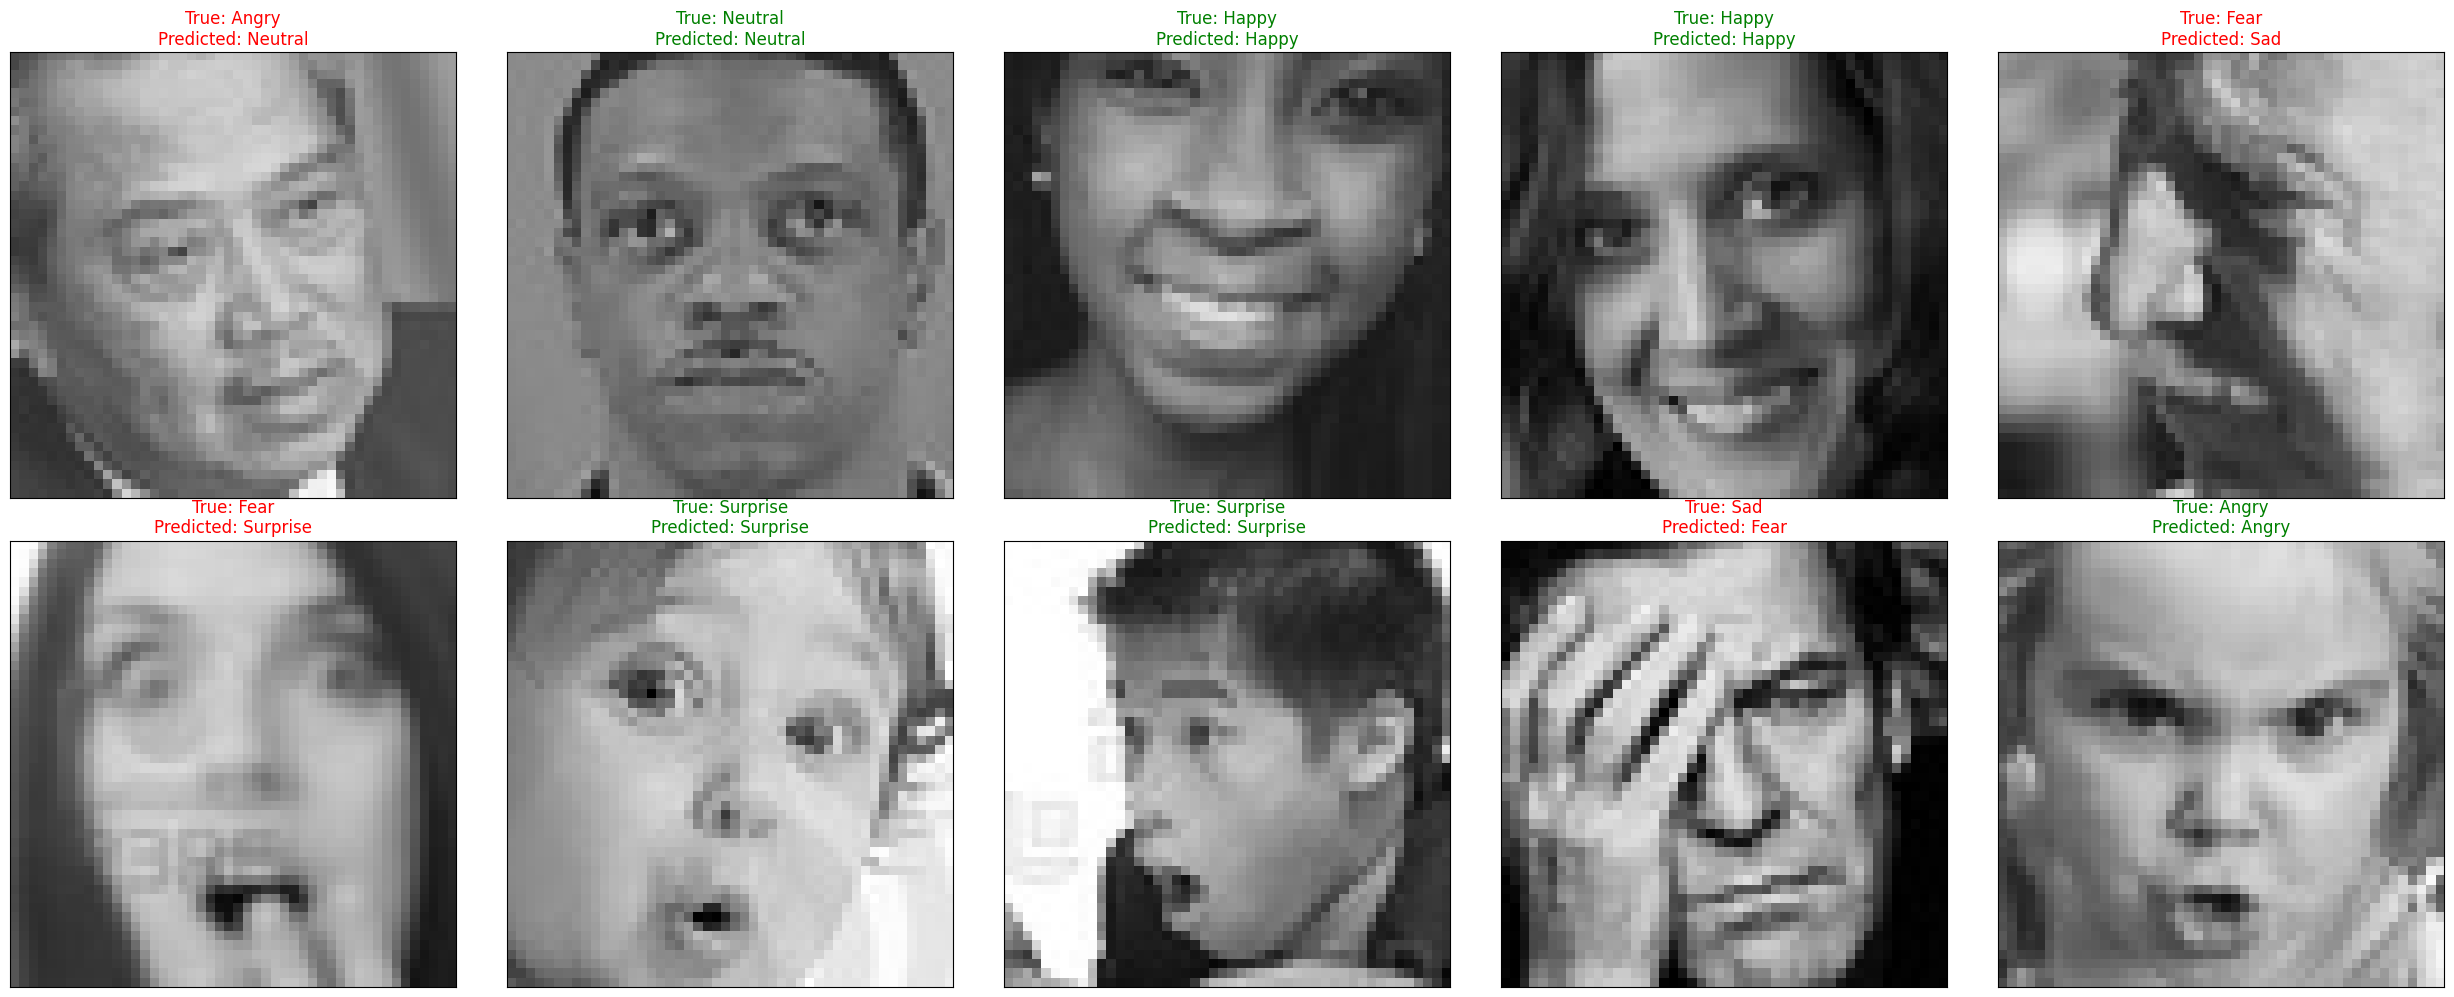

In [34]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Assuming test_generator, CNN_Model, and Emotion_Classes are defined elsewhere

Random_batch = np.random.randint(0, len(test_generator) - 1)

# Select 10 random image indices
Random_Img_Index = np.random.randint(0, batch_size - 1, 10)

# Create subplots for displaying images
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    # Get a random image from the batch
    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    # Resize the image to (48, 48, 3) to match the expected input shape of the CNN model
    Random_Img = tf.image.resize(Random_Img, (48, 48))

    # Get the true label for the image
    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    # Make a prediction using the CNN model
    Model_Prediction = np.argmax(CNN_Model.predict(tf.expand_dims(Random_Img, axis=0), verbose=0))

    # Display the image
    ax.imshow(Random_Img)

    # Check if the true label matches the predicted label and set the color accordingly
    if Emotion_Classes[Random_Img_Label] == Emotion_Classes[Model_Prediction]:
        color = "green"
    else:
        color = "red"

    # Set the title to show the true and predicted labels
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[Model_Prediction]}", color=color)

# Adjust layout to prevent overlapping titles
plt.tight_layout()
plt.show()


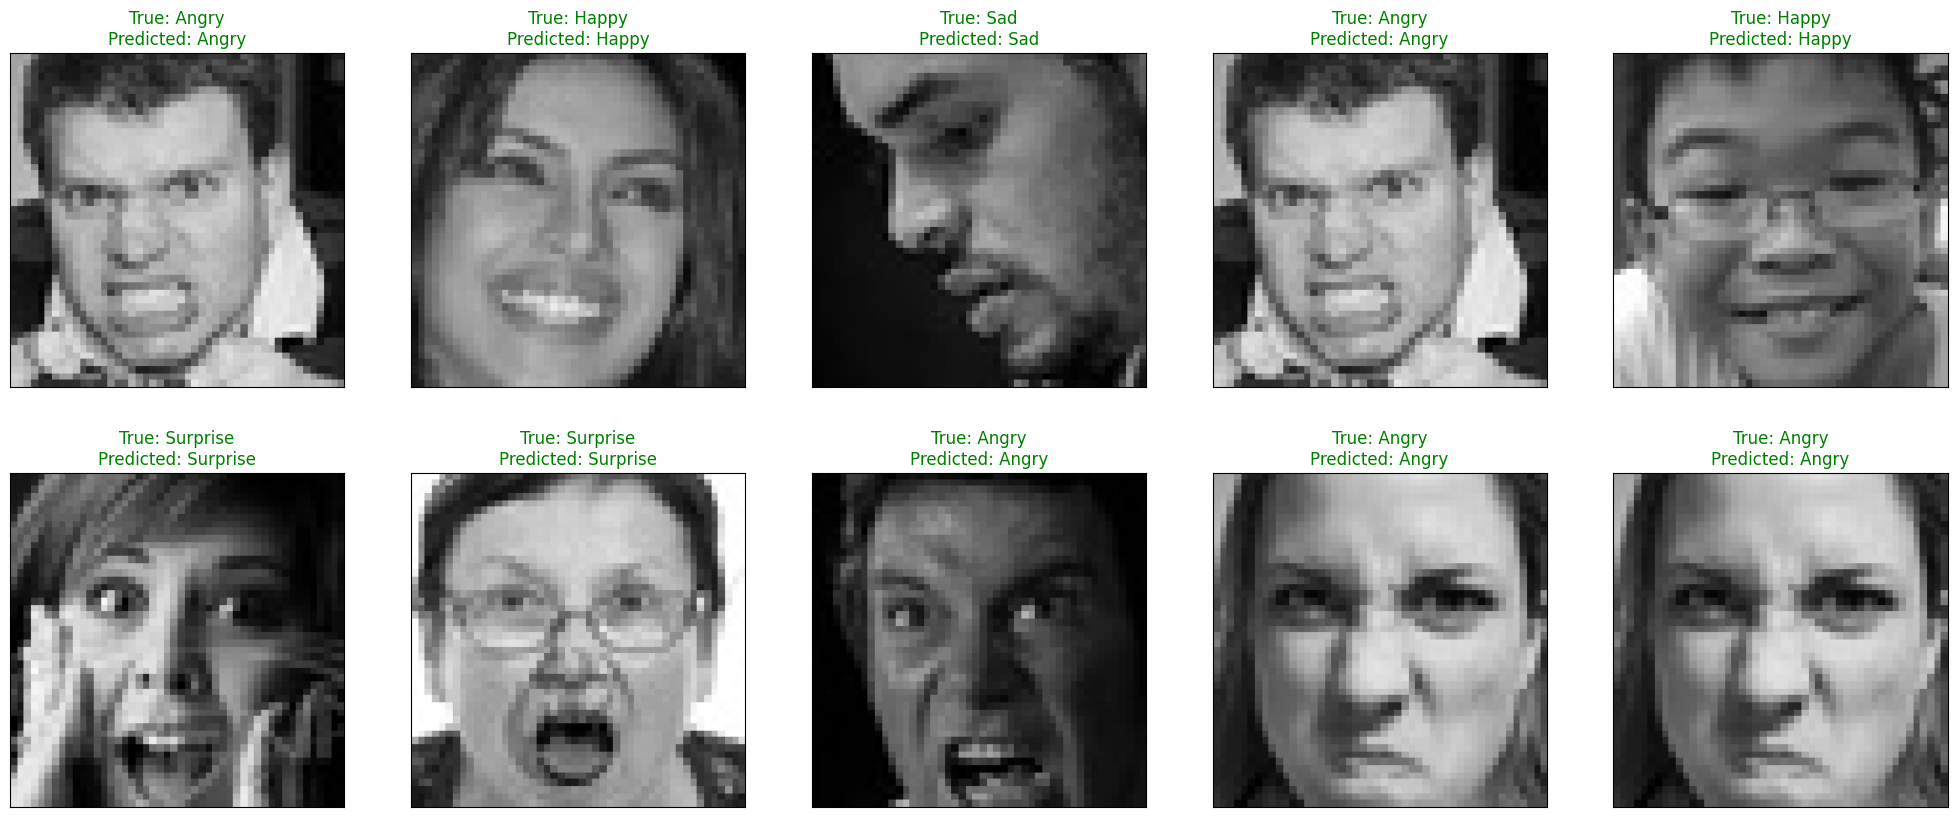

<Figure size 640x480 with 0 Axes>

In [35]:
# Display 10 random pictures from the dataset with their labels

Random_batch = np.random.randint(0, len(test_generator) - 1)

Random_Img_Index = np.random.randint(0, batch_size - 1 , 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    Model_Prediction = np.argmax(ResNet50V2_Model.predict( tf.expand_dims(Random_Img, axis=0) , verbose=0))

    ax.imshow(Random_Img)

    if Emotion_Classes[Random_Img_Label] == Emotion_Classes[Model_Prediction]:
          color = "green"
    else:
          color = "red"
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[Model_Prediction]}", color=color)
plt.show()
plt.tight_layout()

In [36]:
Music_Player = pd.read_csv("/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/data_moods.csv")
Music_Player = Music_Player[['name','artist','mood','popularity']]
Music_Player.head()

,name,artist,mood,popularity
0,1999,Prince,Happy,68
1,23,Blonde Redhead,Sad,43
2,9 Crimes,Damien Rice,Sad,60
3,99 Luftballons,Nena,Happy,2
4,A Boy Brushed Red Living In Black And White,Underoath,Energetic,60


In [37]:
Music_Player["mood"].value_counts()

mood
Sad          197
Calm         195
Energetic    154
Happy        140
Name: count, dtype: int64

In [38]:
Music_Player["popularity"].value_counts()

popularity
0     92
51    23
52    22
50    21
55    21
      ..
80     1
2      1
14     1
15     1
88     1
Name: count, Length: 83, dtype: int64

In [39]:
Play = Music_Player[Music_Player['mood'] =='Calm' ]
Play = Play.sort_values(by="popularity", ascending=False)
Play = Play[:5].reset_index(drop=True)
display(Play)

,name,artist,mood,popularity
0,Lost,Annelie,Calm,64
1,Curiosity,Beau Projet,Calm,60
2,Escaping Time,Benjamin Martins,Calm,60
3,Just Look at You,369,Calm,59
4,Vague,Amaranth Cove,Calm,59


In [40]:
# Making Songs Recommendations Based on Predicted Class
def Recommend_Songs(pred_class):

    if( pred_class=='Disgust' ):

        Play = Music_Player[Music_Player['mood'] =='Sad' ]
        Play = Play.sort_values(by="popularity", ascending=False)
        Play = Play[:5].reset_index(drop=True)
        display(Play)

    if( pred_class=='Happy' or pred_class=='Sad' ):

        Play = Music_Player[Music_Player['mood'] =='Happy' ]
        Play = Play.sort_values(by="popularity", ascending=False)
        Play = Play[:5].reset_index(drop=True)
        display(Play)

    if( pred_class=='Fear' or pred_class=='Angry' ):

        Play = Music_Player[Music_Player['mood'] =='Calm' ]
        Play = Play.sort_values(by="popularity", ascending=False)
        Play = Play[:5].reset_index(drop=True)
        display(Play)

    if( pred_class=='Surprise' or pred_class=='Neutral' ):

        Play = Music_Player[Music_Player['mood'] =='Energetic' ]
        Play = Play.sort_values(by="popularity", ascending=False)
        Play = Play[:5].reset_index(drop=True)
        display(Play)

In [43]:
#!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml

faceCascade = cv2.CascadeClassifier("/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/haarcascade_frontalface_default (1).xml")

In [44]:
def load_and_prep_image(filename, img_shape = 224):

    img = cv2.imread(filename)

    GrayImg = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    faces = faceCascade.detectMultiScale(GrayImg, 1.1, 4)

    for x,y,w,h in faces:

        roi_GrayImg = GrayImg[ y: y + h , x: x + w ]
        roi_Img = img[ y: y + h , x: x + w ]

        cv2.rectangle(img, (x,y), (x+w, y+h), (0, 255, 0), 2)

        plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

        faces = faceCascade.detectMultiScale(roi_Img, 1.1, 4)

        if len(faces) == 0:
            print("No Faces Detected")
        else:
            for (ex, ey, ew, eh) in faces:
                img = roi_Img[ ey: ey+eh , ex: ex+ew ]

    RGBImg = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    RGBImg= cv2.resize(RGBImg,(img_shape,img_shape))

    RGBImg = RGBImg/255.

    return RGBImg

In [45]:
def pred_and_plot(filename, class_names):

    # Import the target image and preprocess it
    img = load_and_prep_image(filename)

    # Make a prediction
    pred = ResNet50V2_Model.predict(np.expand_dims(img, axis=0))

    # Get the predicted class
    pred_class = class_names[pred.argmax()]

    # Plot the image and predicted class
    #plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False);

    Recommend_Songs(pred_class)

1/1 [==============================] - 0s 57ms/step


,name,artist,mood,popularity
0,Chop Suey!,System Of A Down,Energetic,79
1,Killing In The Name,Rage Against The Machine,Energetic,78
2,Dani California,Red Hot Chili Peppers,Energetic,77
3,Duality,Slipknot,Energetic,76
4,Uprising,Muse,Energetic,75


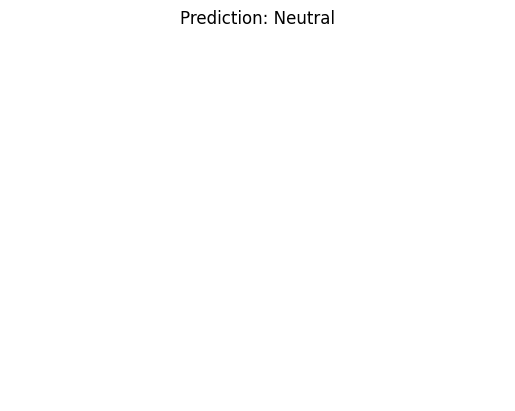

In [47]:
pred_and_plot("/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/archive/test/sad/PrivateTest_1256234.jpg", Emotion_Classes) # with CNN

In [48]:
# Downloading Image to Test On
!wget -c "https://pbs.twimg.com/media/EEY3RFFWwAAc-qm.jpg" -O sad.jpg

zsh:1: command not found: wget


1/1 [==============================] - 0s 91ms/step


,name,artist,mood,popularity
0,Chop Suey!,System Of A Down,Energetic,79
1,Killing In The Name,Rage Against The Machine,Energetic,78
2,Dani California,Red Hot Chili Peppers,Energetic,77
3,Duality,Slipknot,Energetic,76
4,Uprising,Muse,Energetic,75


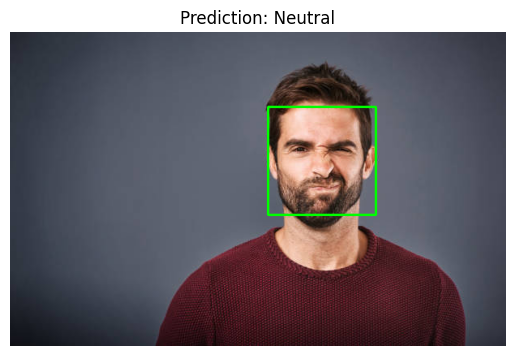

In [49]:
pred_and_plot("/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/istockphoto-1080813354-612x612.jpg", Emotion_Classes) # with CNN

1/1 [==============================] - 0s 56ms/step


,name,artist,mood,popularity
0,Chop Suey!,System Of A Down,Energetic,79
1,Killing In The Name,Rage Against The Machine,Energetic,78
2,Dani California,Red Hot Chili Peppers,Energetic,77
3,Duality,Slipknot,Energetic,76
4,Uprising,Muse,Energetic,75


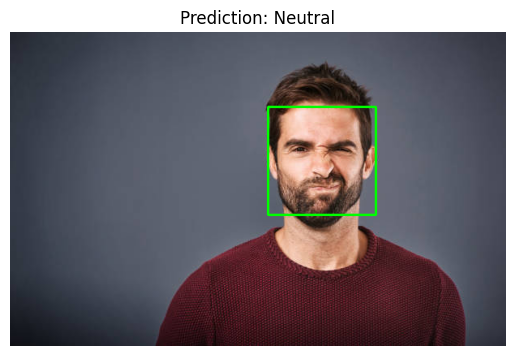

In [50]:
pred_and_plot("/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/istockphoto-1080813354-612x612.jpg", Emotion_Classes) # with ResNet50V2

In [ ]:
# Downloading Image to Test On
!wget -c "https://pbs.twimg.com/profile_images/758370732413947904/xYB5Q3FY_400x400.jpg" -O happy.jpg

1/1 [==============================] - 0s 58ms/step


,name,artist,mood,popularity
0,Chop Suey!,System Of A Down,Energetic,79
1,Killing In The Name,Rage Against The Machine,Energetic,78
2,Dani California,Red Hot Chili Peppers,Energetic,77
3,Duality,Slipknot,Energetic,76
4,Uprising,Muse,Energetic,75


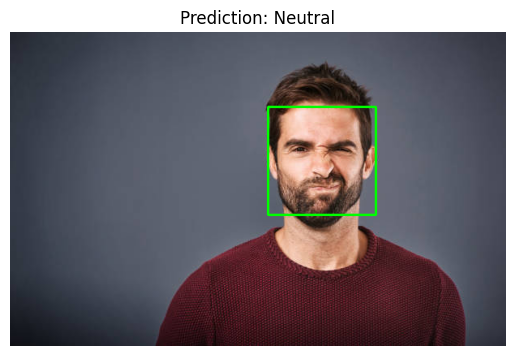

In [52]:
pred_and_plot("/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/istockphoto-1080813354-612x612.jpg", Emotion_Classes) # with ResNet50V2

In [53]:
CNN_Model.save("CNN_Model.h5")

ResNet50V2_Model.save("ResNet50V2_Model.h5")

/Users/harshareddy/Library/Python/3.9/lib/python/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [55]:
%pip install tensorflow yt-dlp opencv-python


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 4.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import yt_dlp
import time

# Load your emotion detection model (assuming it's an .h5 file)
model = tf.keras.models.load_model('/Users/harshareddy/Downloads/Music_Recommendation_System_Through_Expression_Recognition-master/Main/ResNet50V2_Model.h5')

# Emotion classes (you can modify these based on your model's output)
emotion_classes = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Emotion-to-YouTube Song Mapping (modify this with actual YouTube URLs or titles)
emotion_song_map = {
    'Anger': 'https://www.youtube.com/watch?v=J0hpGcahS14',  # Example song
    'Disgust': 'https://www.youtube.com/watch?v=E5bP7UqOVJU',  # Example song
    'Fear': 'https://www.youtube.com/watch?v=kXYiU_JCYtU',  # Example song
    'Happy': 'https://www.youtube.com/watch?v=YbJOTdZBX1g',  # Example song
    'Sad': 'https://www.youtube.com/watch?v=Ra9O9C7KPbM',  # Example song
    'Surprise': 'https://www.youtube.com/watch?v=dQw4w9WgXcQ',  # Example song
    'Neutral': 'https://www.youtube.com/watch?v=5qap5aO4i9A'  # Example song
}

# Initialize the face cascade for detecting faces
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Capture video from the webcam
cap = cv2.VideoCapture(0)

# Run the emotion detection and play music in a loop
while True:
    ret, frame = cap.read()
    
    # Convert the image to grayscale for face detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the image
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    # If faces are detected
    if len(faces) > 0:
        # Extract the first detected face (you can modify this for multiple faces if needed)
        x, y, w, h = faces[0]
        face = frame[y:y + h, x:x + w]
        
        # Preprocess the face image to match the input shape of the model
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)  # Convert to RGB
        face = cv2.resize(face, (224, 224))  # Resize to (224, 224)
        face = face.astype('float32') / 255  # Normalize the image
        face = np.expand_dims(face, axis=0)  # Add batch dimension
        
        # Predict the emotion
        emotion_probs = model.predict(face)
        emotion_label = emotion_classes[np.argmax(emotion_probs)]
        
        # Print the detected emotion on the screen
        cv2.putText(frame, f'Emotion: {emotion_label}', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # If the emotion is detected, play the corresponding song
        if emotion_label in emotion_song_map:
            print(f'Playing song for emotion: {emotion_label}')
            song_url = emotion_song_map[emotion_label]

            # Play the song using yt-dlp
            ydl_opts = {
                'format': 'bestaudio/best',
                'postprocessors': [{
                    'key': 'FFmpegAudioConvertor',  # Corrected postprocessor key
                    'preferredcodec': 'mp3',
                    'preferredquality': '192',
                }],
                'outtmpl': 'downloaded_song.%(ext)s',  # Temporary file name
                'quiet': False,
            }

            with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                ydl.download([song_url])
                
            # Wait for the song to finish playing (for simplicity, we will not play continuously here)
            time.sleep(10)  # Sleep for a while to let the song play

            # Clean up downloaded files (optional)
            try:
                import os
                os.remove('downloaded_song.mp3')
            except:
                pass

    # Display the frame
    cv2.imshow('Emotion Detection', frame)

    # Break on 'ESC' key press
    if cv2.waitKey(1) & 0xFF == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


/Users/harshareddy/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2025-03-17 23:56:42.263 Python[31196:9619971] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-17 23:56:42.263 Python[31196:9619971] +[IMKInputSession subclass]: chose IMKInputSession_Modern


1/1 [==============================] - 0s 425ms/step
Playing song for emotion: Sad


KeyError: 'FFmpegAudioConvertorPP'

: 